In [2]:
from torchvision import transforms
classes = ['False', 'True']
train_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomRotation(25),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor()
])
test_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor()
])

In [3]:
from torchvision.datasets import ImageFolder
train_data = ImageFolder('data/brain_tumors/train/', train_transforms)
test_data = ImageFolder('data/brain_tumors/test/', test_transforms)

In [4]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_data, 
                              16,
                              shuffle=True,
                              num_workers=10,
                              pin_memory=True)
test_dataloader = DataLoader(test_data,
                             32,
                             shuffle=False,
                             num_workers=6,
                             pin_memory=True)

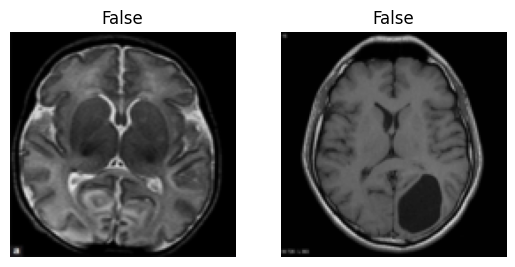

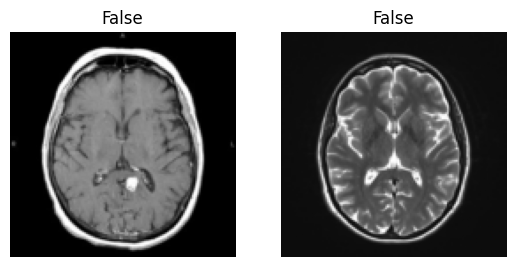

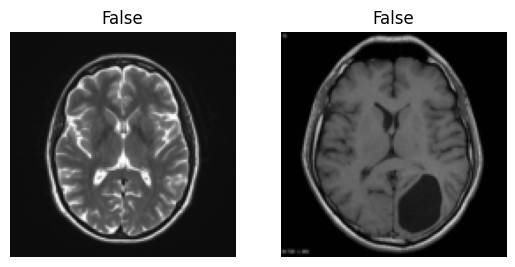

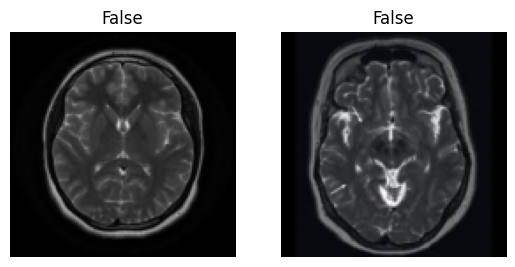

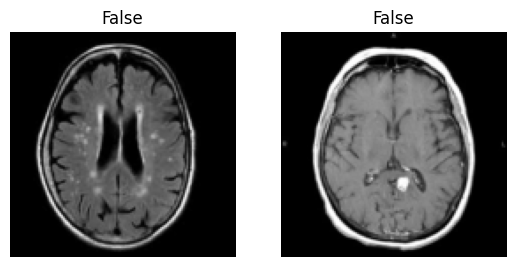

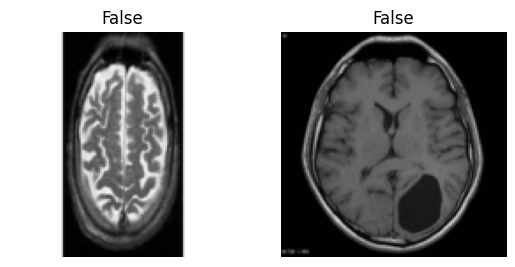

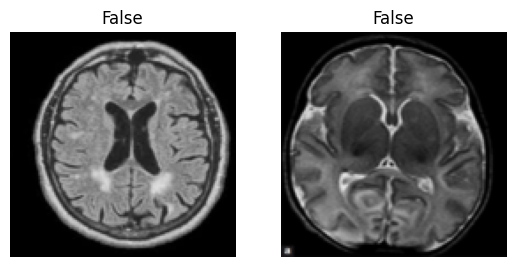

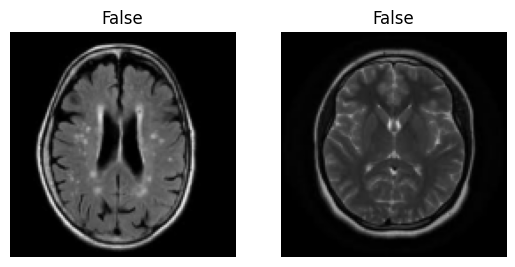

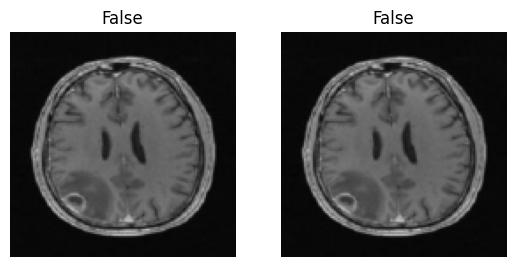

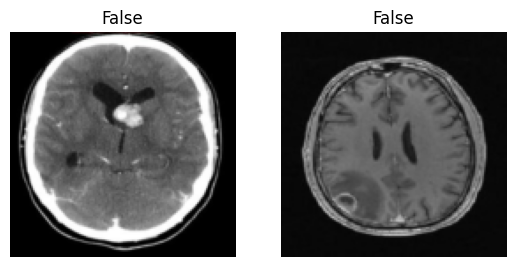

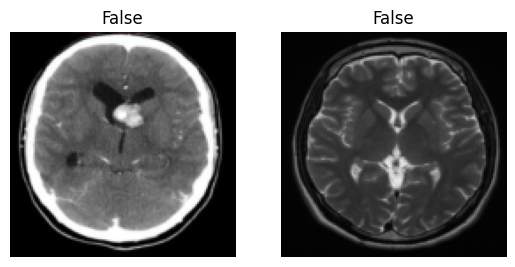

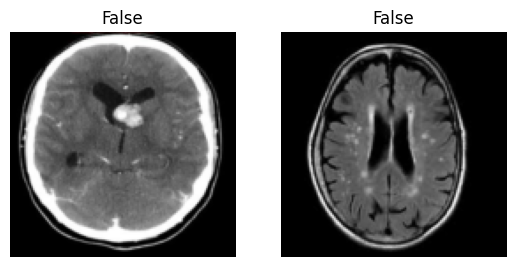

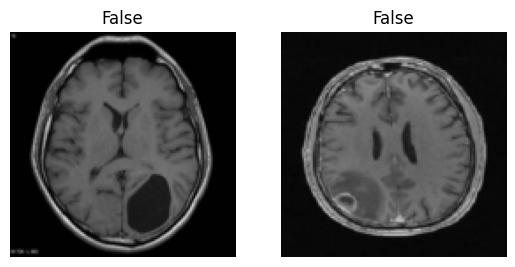

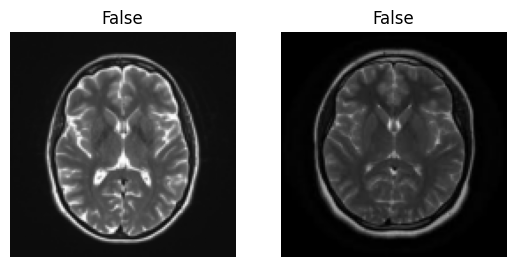

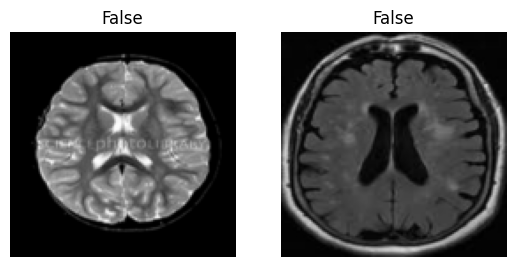

In [5]:
from matplotlib import pyplot as plt
import numpy as np
xb, yb = next(iter(test_dataloader))
for i in range(15):
    ridx = np.random.randint(0, 16)
    img = xb[ridx].squeeze().permute(1, 2, 0)
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(img)
    ax[0].set_title(classes[yb[ridx]])
    ax[0].axis(False)
    ridx = np.random.randint(0, 16)
    img = xb[ridx].squeeze().permute(1, 2, 0)
    ax[1].imshow(img)
    ax[1].set_title(classes[yb[ridx]])
    ax[1].axis(False)

In [ ]:
from torch import nn
import torch
device = 'cuda' if torch.cuda.is_available() else "cpu"
# ...existing code...
class TinyTumorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


model = TinyTumorCNN().to(device)

In [7]:
from torch import optim
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
sheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, 250)

In [8]:
# ...existing code...
from torch import optim
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# create writer once and close after training (not every epoch)
writer = SummaryWriter(log_dir='runs')

epochbatch = len(train_dataloader)


# ...existing code...
def evaluate_model(model, loader, device):
    """Calculates the accuracy of the model on the test/validation set."""
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, device):
    best_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (inputs, targets) in enumerate(train_bar):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # step scheduler per batch if appropriate
            scheduler.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            train_bar.set_postfix({
                'Loss': f'{train_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Evaluate on the test set after each epoch
        test_acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy after Epoch {epoch+1}: {test_acc:.2f}%")
        writer.add_scalar('Epoch/acc', test_acc, epoch)
        # DO NOT close writer here

        if test_acc > best_acc:
            best_acc = test_acc
            print(f"** New best model saved with accuracy: {best_acc:.2f}% **")
            # save checkpoint if desired

    # close writer after training completes
    writer.close()
    torch.cuda.empty_cache()
    print(f"\nTraining complete. Best Test Accuracy: {best_acc:.2f}%")
# ...existing code...

In [20]:
train_model(model, train_dataloader, test_dataloader, criterion, optimizer, sheduler, 250, device)

Starting training on cuda...


Epoch 1/250: 100%|██████████| 13/13 [00:00<00:00, 38.32it/s, Loss=0.7261, Acc=39.60%, LR=0.000137]


Test Accuracy after Epoch 1: 39.22%
** New best model saved with accuracy: 39.22% **


Epoch 2/250: 100%|██████████| 13/13 [00:00<00:00, 40.27it/s, Loss=0.7339, Acc=39.60%, LR=0.000161]


Test Accuracy after Epoch 2: 39.22%


...

Test Accuracy after Epoch 85: 39.22%


Epoch 86/250: 100%|██████████| 13/13 [00:00<00:00, 39.97it/s, Loss=0.7231, Acc=39.60%, LR=0.000291]


Test Accuracy after Epoch 86: 39.22%


Epoch 87/250:  23%|██▎       | 3/13 [00:00<00:01,  9.97it/s, Loss=0.7201, Acc=31.25%, LR=0.000293]


KeyboardInterrupt: 

In [10]:
# Function to make a prediction on a single image
def predict_single_image(model, image_tensor, device):
    # 1. Ensure the model is in evaluation mode
    model.eval()
    
    # 2. Add a batch dimension and move to the device (GPU)
    # The model expects [Batch, Channel, Height, Width]. 
    # Our image_tensor is currently [1, 28, 28]. We need to add the batch dim.
    input_tensor = image_tensor.unsqueeze(0).to(device)
    
    # 3. Disable gradient tracking
    with torch.no_grad():
        # 4. Forward Pass: Get the logits
        output_logits = model(input_tensor)
    
    # 5. Convert logits to class index
    # argmax(dim=1) gets the highest score's index, which is the predicted digit
    predicted_class = output_logits.argmax(dim=1).item()
    
    return predicted_class

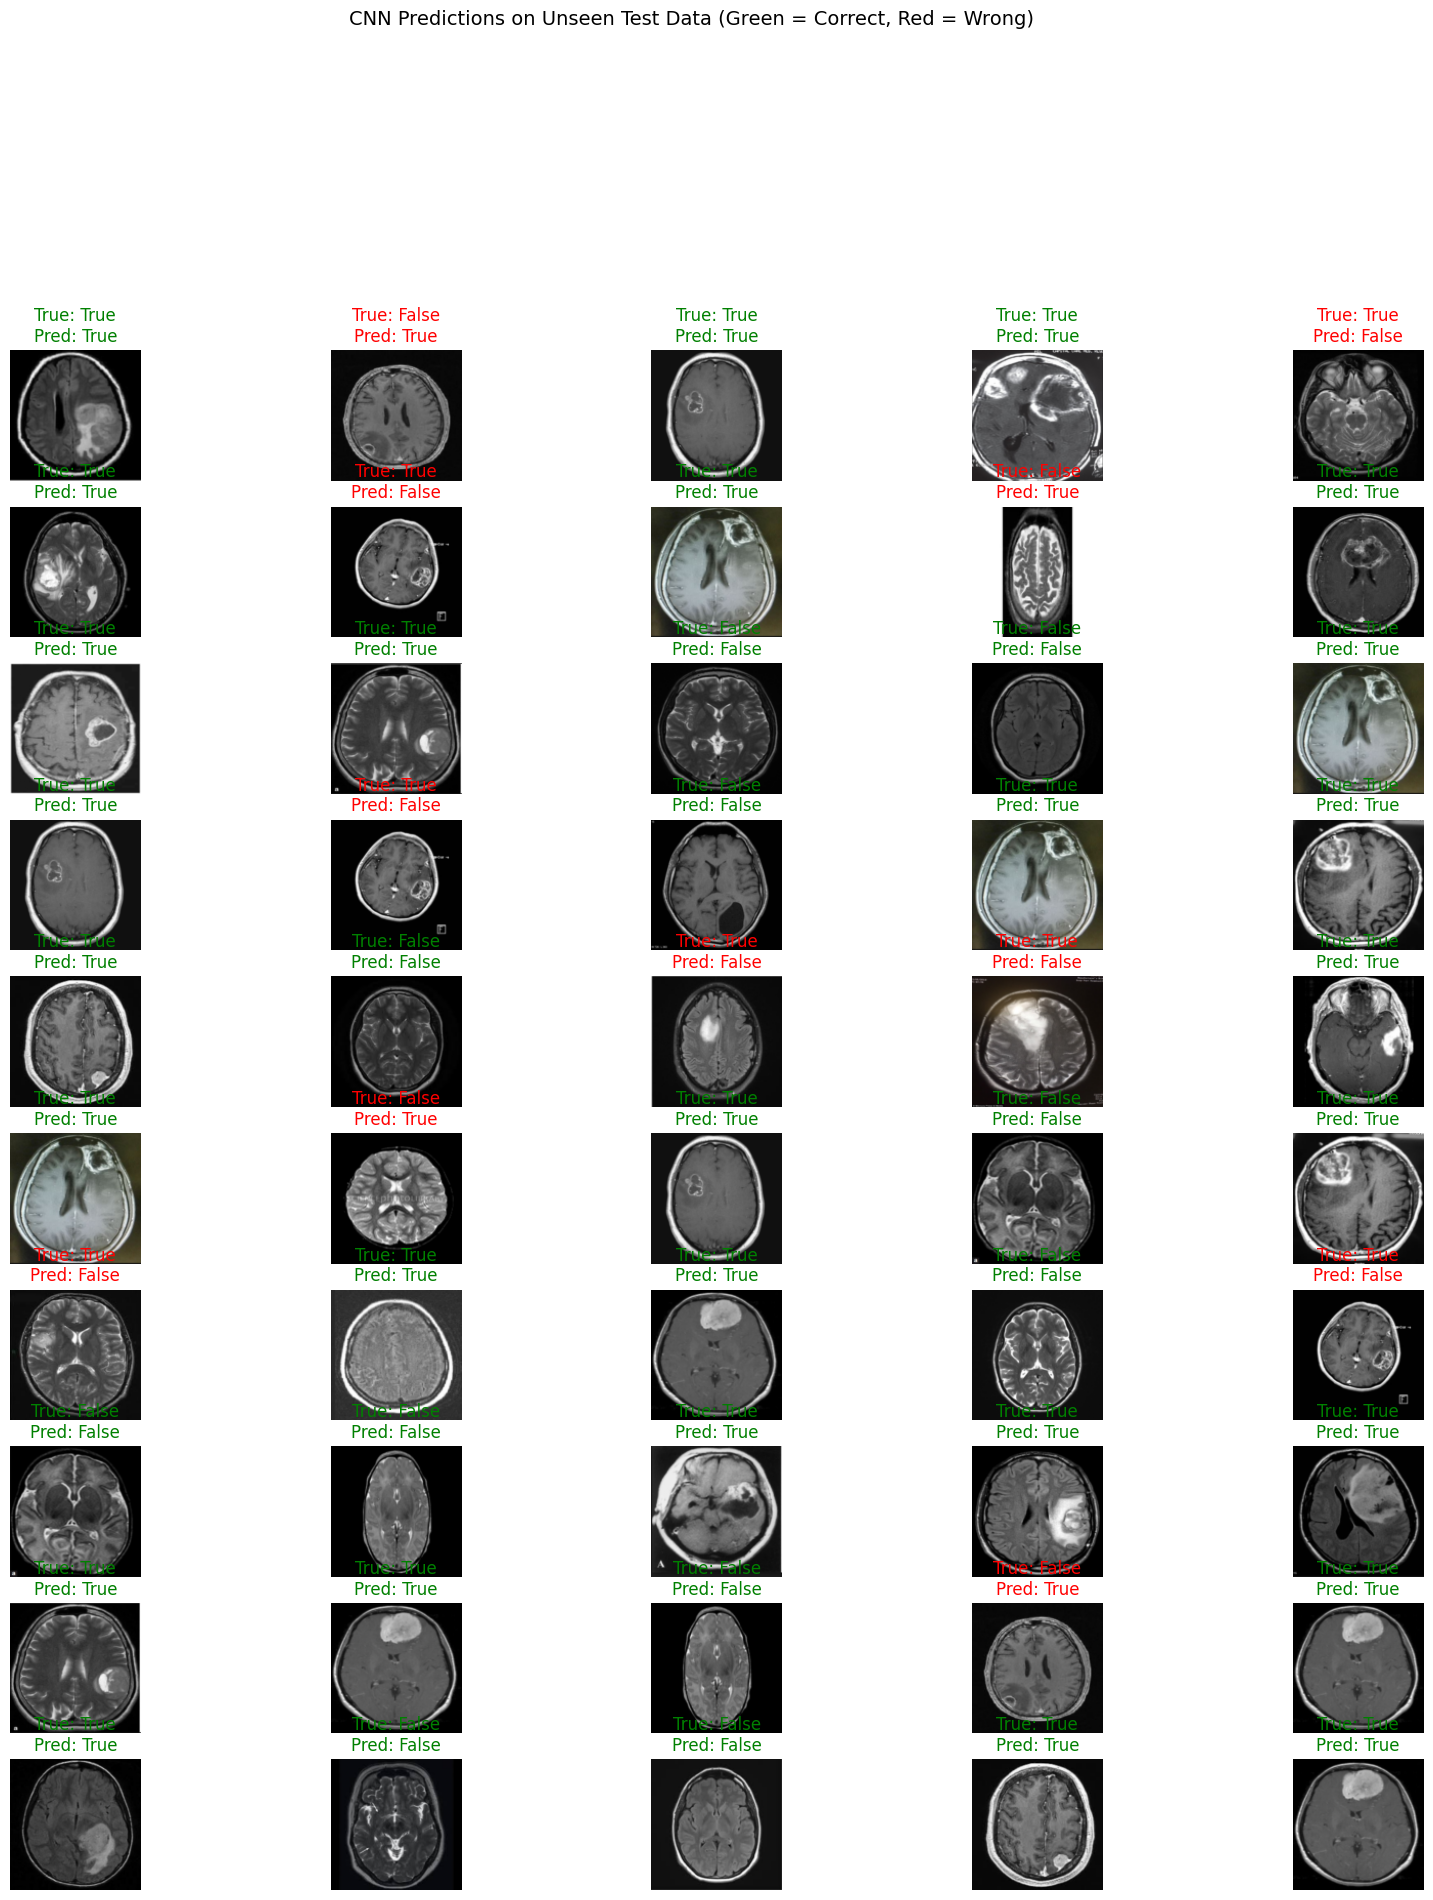

In [11]:
# Grab the first 5 samples from the raw test dataset
test_samples = []
plotting_dataloader = DataLoader(test_data, 16, shuffle=True)
for i in range(50):
    # Get the raw tensor and true label from the dataset
    ridx = np.random.randint(0, 16)
    x, y = next(iter(plotting_dataloader))
    image_tensor=x[ridx]
    true_label = y[ridx].item()
    # Get the model's prediction
    predicted_label = predict_single_image(model, image_tensor, device)
    
    # Denormalize the image for display (if you used simple transform, 
    # it's already 0-1 and this is fine)
    image_display = image_tensor.squeeze()
    
    test_samples.append({
        'image': image_display, 
        'true': true_label, 
        'predicted': predicted_label
    })

# Plotting the results
plt.figure(figsize=(20, 20))
for i, sample in enumerate(test_samples):
    ax = plt.subplot(10, 5, i + 1)
    sample['image'] = sample['image'].permute(1, 2, 0)
    plt.imshow(sample['image'], cmap="gray")
    
    color = 'green' if sample['predicted'] == sample['true'] else 'red'
    title = f"True: {classes[sample['true']]}\nPred: {classes[sample['predicted']]}"
    
    plt.title(title, color=color)
    plt.axis("off")

plt.suptitle(
    "CNN Predictions on Unseen Test Data (Green = Correct, Red = Wrong)", 
    y=1.05, 
    fontsize=14
)
plt.show()

In [12]:
from torchvision import datasets, transforms

test = datasets.ImageFolder(
    root="~/torch/data/brain_tumors/test",
    transform=transforms.ToTensor()
)

print(test.classes)
print(len(test))


['False', 'True']
51
